<a href="https://colab.research.google.com/github/erskordi/ME561/blob/main/ML4A_HW4_PP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HW 4 - Pair Programming Activities**

Submission requirements [1 pt]

*   a shared link (website URL) where results can be reproduced
*   a pdf show codes, results, and plots



## **Activity 1** - Hands-on problem


*   Build and train your first NN (Check details from video 3.5)
*   No pts for this activity.

In [1]:
#### No submission needed for Activity 1

## **Activity 2 [2 pts]** - Redo the Hands-on problem with **PyTorch**

*   **[0.5 pts]** data generation
*   **[0.5 pts]** training with the data
*   **[0.5 pts]** prediction
*   **[0.5 pts]** plot data and predict in one plot

PS: Refer to sample code from video 3.5, such as loss function, activation function, etc.

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Seeds for reproducibility
torch.manual_seed(19)
np.random.seed(19)

In [3]:
# build your NN
model = nn.Sequential(
    nn.Linear(1, 2),
    nn.ReLU(),        # activation function
    nn.Linear(2, 1)
)
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)


Epoch 1, Training loss 2.3966
Epoch 1000, Training loss 0.0418
Epoch 2000, Training loss 0.0103
Epoch 3000, Training loss 0.0102
Epoch 4000, Training loss 0.0102
Epoch 5000, Training loss 0.0102


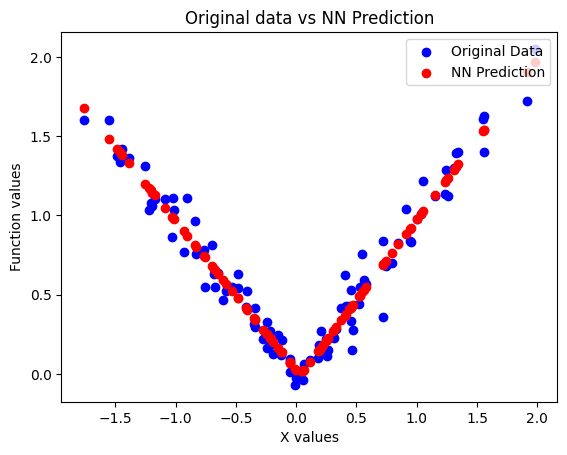

In [4]:
###############################
#### Your code starts here ####
###############################
# data generation
X = np.sort(np.random.randn(100))
Y = np.abs(X) + 0.1 * np.random.randn(100)

# training with the data
def training_loop(n_epochs, optimizer, model, loss_fn, data, labels):
  model.train()
  for epoch in range(1, n_epochs + 1):
      preds = model(data)
      loss_train = loss_fn(preds, labels)

      optimizer.zero_grad()
      loss_train.backward()
      optimizer.step()

      if epoch == 1 or epoch % 1000 == 0:
          print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}")

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.MSELoss(),
    data=torch.tensor(X).float().reshape(-1, 1),
    labels=torch.tensor(Y).float().reshape(-1, 1)
)

# prediction
Y_hat = model(torch.tensor(X).float().reshape(-1, 1)).detach().numpy()

plt.scatter(X, Y, label="Original Data", color='blue')
plt.scatter(X, Y_hat, label="NN Prediction", color='red')
plt.xlabel("X values")
plt.ylabel("Function values")
plt.title("Original data vs NN Prediction")
plt.legend(loc='upper right')
plt.show()

###############################
####  Your code ends here  ####
###############################

## **Activity 3 [4 pts]** - Working on a new NN with pytorch

*   **[0.5 pts]** build the new NN (see picture below)
*   **[0.5 pts]** build the $M=3$ polynnomial model c.f. example in video 3.3
*   **[1 pt]** training both models with the given data
*   **[1 pt]** predictions (both models)
*   **[1 pt]** plot data and predictions (both models) in one plot


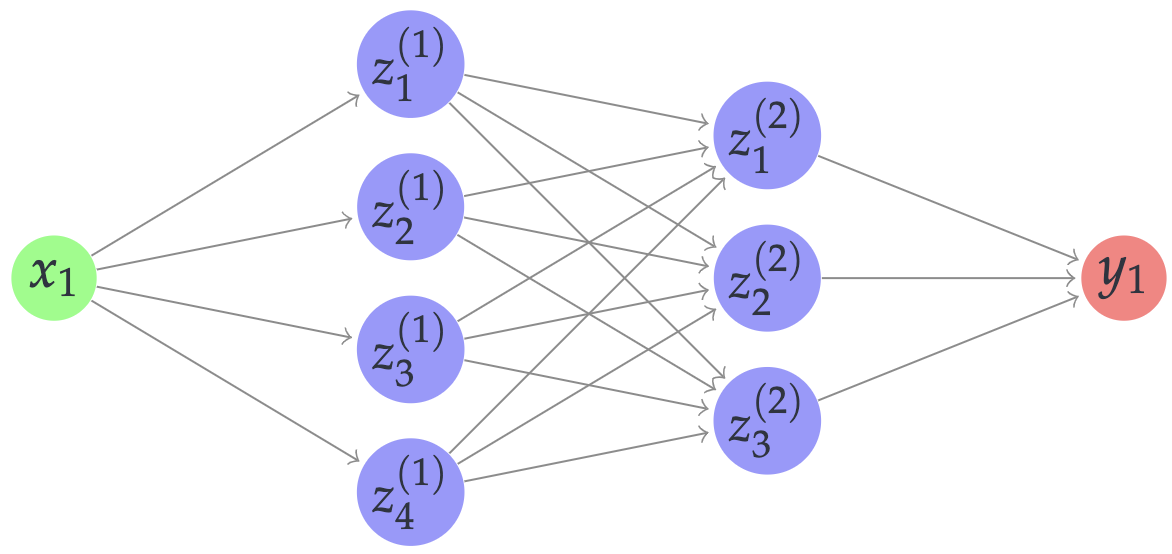

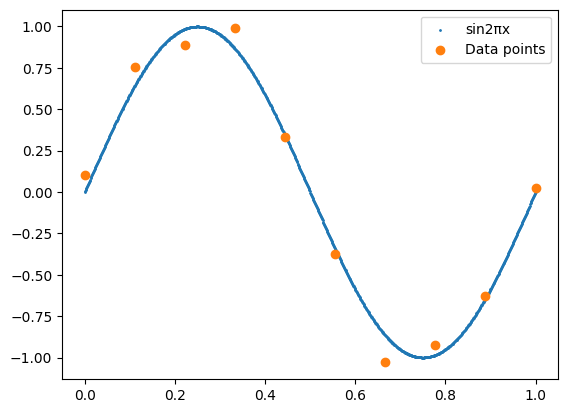

In [5]:
# data generation
x = torch.linspace(0, 1, 10).reshape(-1, 1)
y = torch.sin(2 * torch.pi * x) + 0.1 * torch.randn(x.size())
# data visualization
x_v = torch.linspace(0, 1, 1000).reshape(-1, 1)
y_v = torch.sin(2 * torch.pi * x_v)
plt.scatter(x_v, y_v, label='sin2πx', s=1)
plt.scatter(x.numpy(), y.numpy(), label='Data points')
plt.legend()

Because the target values are constrained between $[-1, 1]$, the ```ReLU``` activation function is not the best to use. I switched to ```Tanh``` which outputs always in this range.

Sequential(
  (0): Linear(in_features=1, out_features=4, bias=True)
  (1): Tanh()
  (2): Linear(in_features=4, out_features=3, bias=True)
  (3): Tanh()
  (4): Linear(in_features=3, out_features=1, bias=True)
)
Epoch 1, Training loss 0.8833
Epoch 5000, Training loss 0.1714
Epoch 10000, Training loss 0.0605
Epoch 15000, Training loss 0.0275
Epoch 20000, Training loss 0.0065


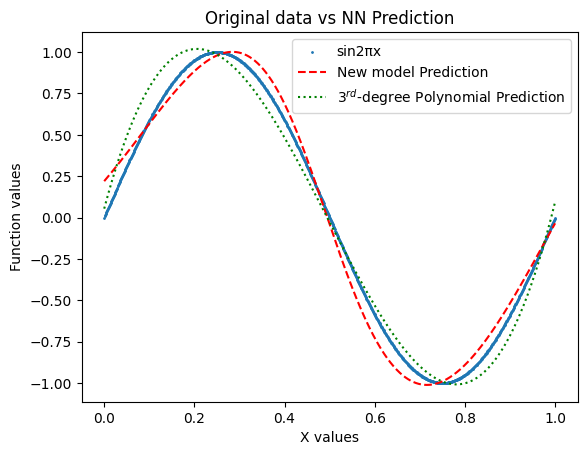

NN relative error: 25.7%
Polynomial relative error: 14.9%


In [6]:
###############################
#### Your code starts here ####
###############################
# build the new NN
new_model = nn.Sequential(
    nn.Linear(1, 4),
    nn.Tanh(),
    nn.Linear(4, 3),
    nn.Tanh(),
    nn.Linear(3, 1)
)
print(new_model)
# build the polynnomial model
logits = np.polyfit(x.squeeze().numpy(), y.numpy(), deg=3)
preds = np.poly1d(logits.squeeze())

# training with the data
def training_loop(n_epochs, optimizer, model, loss_fn, data, labels):
  model.train()
  for epoch in range(1, n_epochs + 1):
      preds = model(data)
      loss_train = loss_fn(preds, labels)

      optimizer.zero_grad()
      loss_train.backward()
      optimizer.step()

      if epoch == 1 or epoch % 5000 == 0:
          print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}")

optimizer = torch.optim.SGD(new_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 20000,
    optimizer = optimizer,
    model = new_model,
    loss_fn = nn.MSELoss(),
    data=x,
    labels=y.reshape(-1, 1)
)

# predictions
Y_hat = new_model(x_v).detach().numpy()

# plot data and predictions in one plot
plt.scatter(x_v, y_v, label='sin2πx', s=1)
plt.plot(x_v, Y_hat, label="New model Prediction", color='red', ls="dashed")
plt.plot(x_v, preds(x_v), label=r"$3^{rd}$-degree Polynomial Prediction", color='green', ls="dotted")
plt.xlabel("X values")
plt.ylabel("Function values")
plt.title("Original data vs NN Prediction")
plt.legend(loc='upper right')
plt.show()

# Relative errors
nn_error = np.mean(np.abs((y_v.squeeze().numpy() - Y_hat.squeeze()) / (y_v.squeeze().numpy()+1e-5)))
poly_error = np.mean(np.abs((y_v.squeeze().numpy() - preds(x_v.squeeze().numpy())) / (y_v.squeeze().numpy() + 1e-5)))

print(f"NN relative error: {nn_error:.1f}%")
print(f"Polynomial relative error: {poly_error:.1f}%")

###############################
####  Your code ends here  ####
###############################